In [207]:
import cv2
import matplotlib.pyplot as plt

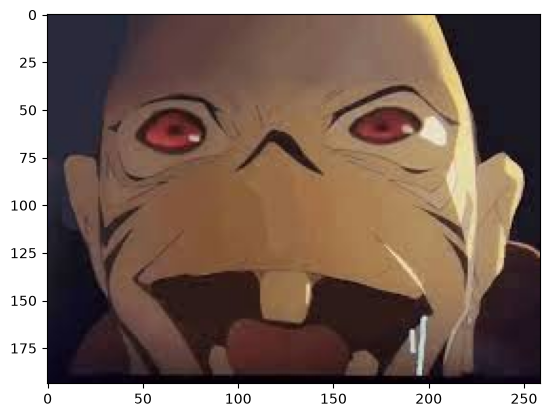

In [208]:
img = cv2.imread("Sukuna.jpg")

if img is None:
    raise FileNotFoundError()

# this changes the default color format from BGR to RGB (the standard one)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()

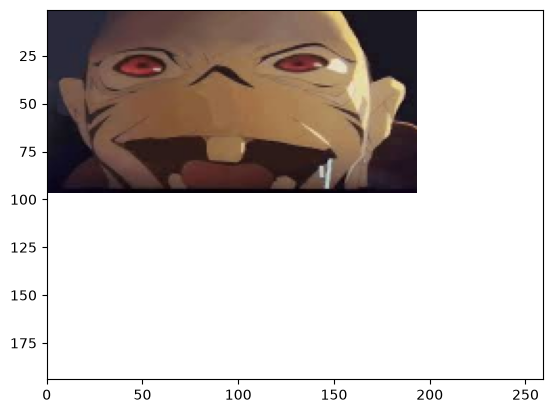

In [209]:
# time to resize the image

# second parameter is for desired fixed size instead of scaling
img_resize = cv2.resize(img_rgb, None, fx=0.75, fy=0.5)

# last parameter (after the scaling) is for interpolation on how to fill
# missing pixel space. You can find all the interpolation methods from 
# cv2.INTER_* where cv2.INTER_LINEAR is default

plt.xlim(0, img_rgb.shape[1])
plt.ylim(img_rgb.shape[0])
plt.imshow(img_resize)

plt.show()

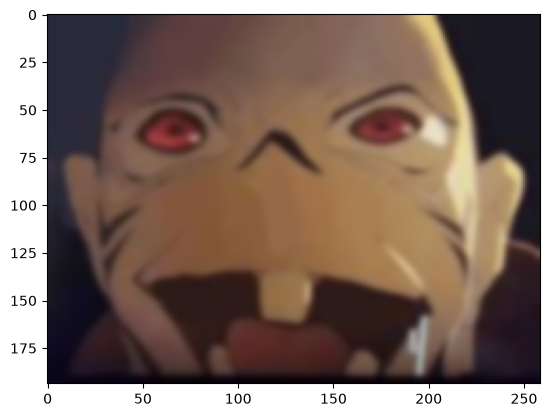

In [210]:
# blurring images

# kernel size should have positive and odd values
# the sigmaX and sigmaY can be kept to 0 to be autocalculated. Otherwise you can define them as well
img_blurred = cv2.GaussianBlur(img_rgb, (9, 9), 0)

plt.imshow(img_blurred)
plt.show()

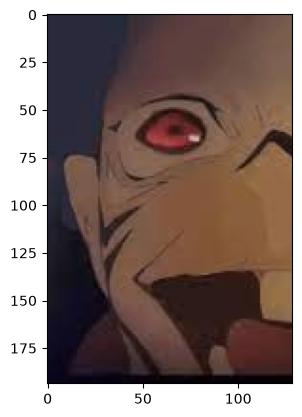

In [211]:
# cropping

# you can crop image using numpy semantics

m, n, _ = img.shape
img_cropped = img_rgb[:, :n//2]

plt.imshow(img_cropped)
plt.show()

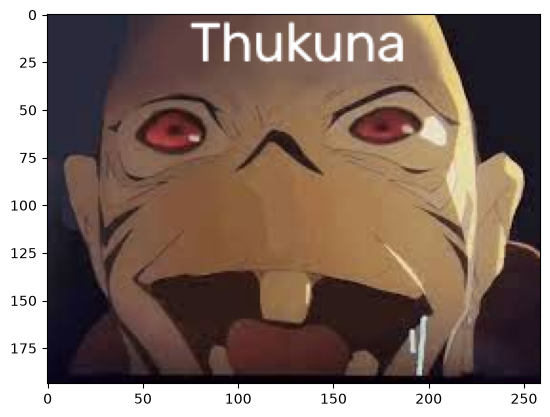

In [212]:
from copy import deepcopy

# adding text to image

img_txt = deepcopy(img_rgb)

cv2.putText(img_txt, "Thukuna", (75, 25), cv2.FONT_HERSHEY_COMPLEX, 1, (255, 255, 255), 0)

plt.imshow(img_txt)
plt.show()

In [213]:
# using pandas to analyze an image

import pandas as pd

df = pd.DataFrame(img_rgb.reshape(-1, 3), columns=["R", "G", "B"])

df.describe()

,R,G,B
count,50246.000000,50246.000000,50246.000000
mean,102.265235,76.778848,64.153405
std,56.695471,48.123796,32.751688
min,0.000000,0.000000,0.000000
25%,45.000000,30.000000,35.000000
50%,111.000000,81.000000,63.000000
75%,146.000000,110.000000,83.000000
max,255.000000,241.000000,230.000000


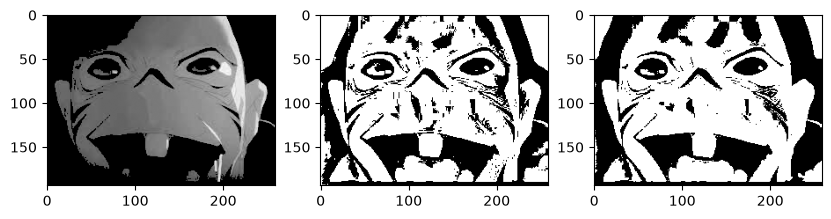

In [214]:
# image thresholding

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# normal thresholding
ret, img_thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_TOZERO | cv2.THRESH_OTSU)


def adaptive(method):
    return cv2.adaptiveThreshold(
        img_gray,
        maxValue=255,
        adaptiveMethod=method,
        thresholdType=cv2.THRESH_BINARY,
        blockSize=55,
        C=2,
    )


# adaptive thresholding
img_adaptive_gaussian = adaptive(cv2.ADAPTIVE_THRESH_GAUSSIAN_C)
img_adaptive_mean = adaptive(cv2.ADAPTIVE_THRESH_MEAN_C)

plt.figure(figsize=(10, 8))
plt.subplot(1, 3, 1)
plt.imshow(img_thresh, cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(img_adaptive_gaussian, cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(img_adaptive_mean, cmap="gray")
plt.show()

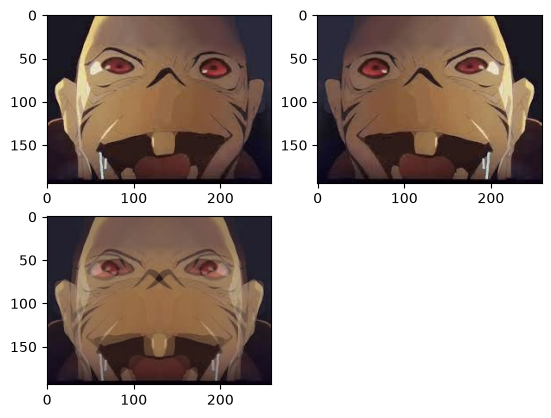

In [215]:
# blending images (just add them)

import numpy as np

m, n = img.shape[:2]
img_flipped = cv2.warpAffine(img_rgb, np.array([[-1, 0, n], [0, 1, 0]], dtype=np.float32), (n, m))

plt.subplot(2, 2, 1)
plt.imshow(img_flipped)
plt.subplot(2, 2, 2)
plt.imshow(img_rgb)
plt.subplot(2, 2, 3)
plt.imshow(cv2.addWeighted(img_rgb, 0.5, img_flipped, 0.5, 0))
plt.show()

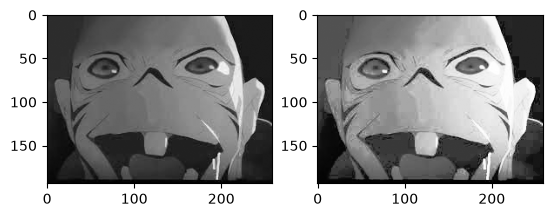

In [216]:
# histogram equilization

img_gray = cv2.imread("Sukuna.jpg", cv2.IMREAD_GRAYSCALE)

# it spreads bars on the histogram uniformly to potentially improve the contrast of the image
img_gray_equalized = cv2.equalizeHist(img_gray)

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img_gray_equalized, cmap="gray")
plt.show()

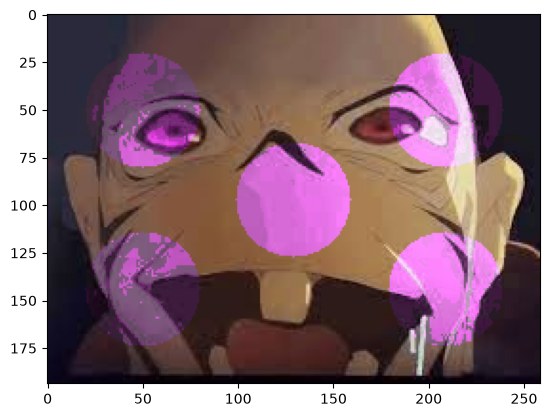

In [220]:
# bitwise operations

n, m = img.shape[:2]
mask = np.zeros((n, m), dtype=np.uint8)
mask_inv = cv2.bitwise_not(mask)

rad = 30
cv2.circle(mask, (50, 50), rad, 255, -1)
cv2.circle(mask, (m - 50, n - 50), rad, 255, -1)
cv2.circle(mask, (50, n - 50), rad, 255, -1)
cv2.circle(mask, (m - 50, 50), rad, 255, -1)
cv2.circle(mask, (m // 2, n // 2), rad, 255, -1)

fg = cv2.bitwise_and(img, img, mask=mask)
bg = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_inv)

img_combined = cv2.bitwise_or(fg, bg)

plt.imshow(img_combined)
plt.show()